# 보조 단계 — 생존 분석 (Survival Analysis)

**목적**: 사용자가 "활성" 상태를 유지하는 기간을 분석하고, 어떤 행동이 활성 수명을 연장하는지 검증한다.  
**사용 데이터**: `06_survival_20260524.csv`  
**이벤트 정의**: `event_dormant=1` (휴면 전환 = 이벤트 발생), `event_dormant=0` (여전히 활성 = 중도절단)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import warnings
warnings.filterwarnings('ignore')


BASE = "../data"
df = pd.read_csv(f"{BASE}/06_survival_20260524.csv")
df['duration_days'] = df['duration_days'].clip(lower=0.5)  # 0일 → 0.5일 처리

print(f"전체: {len(df)}명")
print(f"이벤트 발생(휴면): {df['event_dormant'].sum()}명")
print(f"중도절단(활성 유지): {(df['event_dormant']==0).sum()}명")
print(f"\nduration_days 중앙값: {df['duration_days'].median():.1f}일")

import matplotlib.font_manager as fm
fm.fontManager.addfont('/Users/hongseogju/anaconda3/lib/python3.11/site-packages/koreanize_matplotlib/fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

/Users/hongseogju/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


전체: 1078명
이벤트 발생(휴면): 991명
중도절단(활성 유지): 87명

duration_days 중앙값: 5.0일


## 모델 선택 근거

- **Kaplan-Meier + Log-rank**: 단변수 생존 곡선 비교. 특정 행동의 유무로 두 그룹을 나누어 생존 분포 차이를 비모수적으로 검정. 가정이 최소화되어 직관적 시각화가 가능하며, 표본 수 제한이 있는 본 데이터(활성 87명)에 적합.
- **Cox 비례 위험 모델**: 다변수 동시 투입으로 각 변수의 **독립적** 효과(위험비, HR)를 추정. 단순 상관관계와 인과 경로를 구분할 수 있는 유일한 방법.
- **대안 기각**: 모수적 생존 모델(Weibull, Exponential)은 생존 함수의 형태를 가정해야 하는데, 본 데이터의 생존 곡선이 특정 분포를 따른다고 가정하기 어려움.


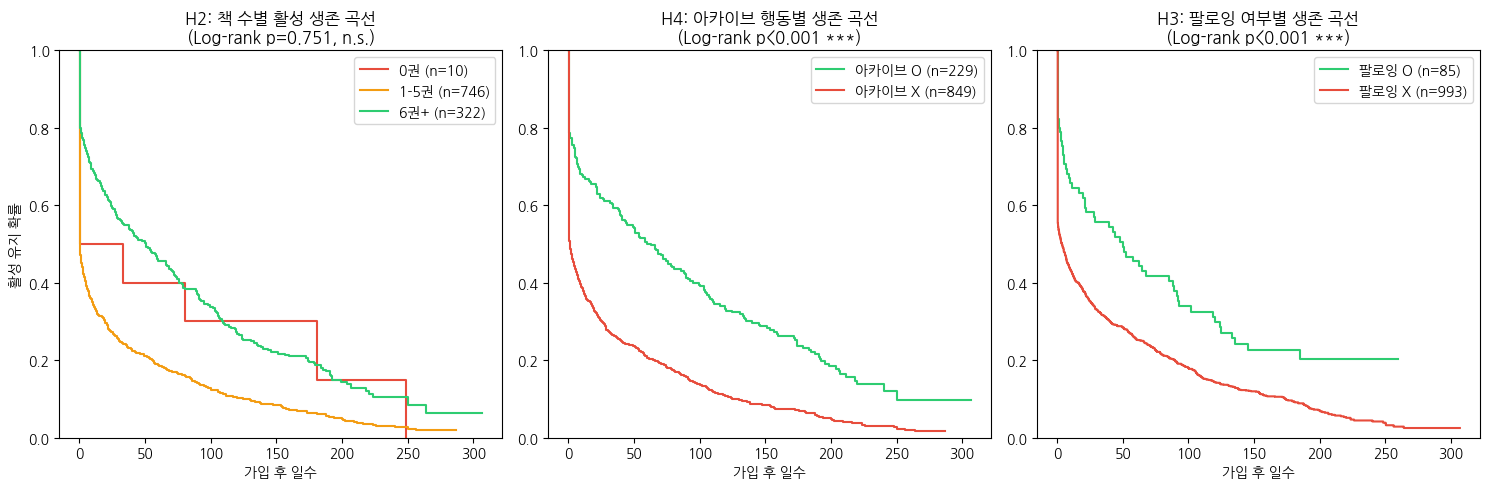

In [2]:
# Kaplan-Meier: H2, H3, H4 동시 시각화
df['book_group'] = pd.cut(df['total_books'], bins=[-1,0,5,200], labels=['0권','1-5권','6권+'])
kmf = KaplanMeierFitter()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# H2: 책 수
for grp, color in [('0권','#e74c3c'),('1-5권','#f39c12'),('6권+','#2ecc71')]:
    mask = df['book_group'] == grp
    kmf.fit(df.loc[mask,'duration_days'], df.loc[mask,'event_dormant'], label=f'{grp} (n={mask.sum()})')
    kmf.plot_survival_function(ax=axes[0], color=color, ci_show=False)
axes[0].set_title('H2: 책 수별 활성 생존 곡선\n(Log-rank p=0.751, n.s.)')
axes[0].set_xlabel('가입 후 일수'); axes[0].set_ylabel('활성 유지 확률')
axes[0].set_ylim(0,1)

# H4: 아카이브
for grp, label, color in [(1,'아카이브 O','#2ecc71'),(0,'아카이브 X','#e74c3c')]:
    mask = df['has_unarchived'] == grp
    kmf.fit(df.loc[mask,'duration_days'], df.loc[mask,'event_dormant'], label=f'{label} (n={mask.sum()})')
    kmf.plot_survival_function(ax=axes[1], color=color, ci_show=False)
axes[1].set_title('H4: 아카이브 행동별 생존 곡선\n(Log-rank p<0.001 ***)')
axes[1].set_xlabel('가입 후 일수'); axes[1].set_ylim(0,1)

# H3: 팔로잉
for cond, label, color in [(True,'팔로잉 O','#2ecc71'),(False,'팔로잉 X','#e74c3c')]:
    mask = (df['following_count'] > 0) == cond
    kmf.fit(df.loc[mask,'duration_days'], df.loc[mask,'event_dormant'], label=f'{label} (n={mask.sum()})')
    kmf.plot_survival_function(ax=axes[2], color=color, ci_show=False)
axes[2].set_title('H3: 팔로잉 여부별 생존 곡선\n(Log-rank p<0.001 ***)')
axes[2].set_xlabel('가입 후 일수'); axes[2].set_ylim(0,1)

plt.tight_layout()
plt.savefig('../notebooks/fig_06_km_curves.png', dpi=150)
plt.show()


## 인사이트 — Kaplan-Meier

| 가설 | Log-rank p | 결론 |
|------|-----------|------|
| H2: 책 수 많으면 휴면률 低 | 0.751 | **기각** — 책 수 자체는 활성 수명과 무관 |
| H3: 팔로잉 → 활성 수명 長 | <0.001 *** | **지지** — 팔로잉 있으면 유의하게 오래 활성 |
| H4: 아카이브 → 활성 수명 長 | <0.001 *** | **지지** — 아카이브 경험자가 유의하게 오래 활성 |

**H2 기각의 해석**: 책을 얼마나 추가했느냐가 아니라 **어떻게 활용했느냐(아카이브)**가 중요.  
책 추가는 탐색 행동이고, 아카이브는 "이 앱을 도구로 쓰겠다"는 정착 선언.


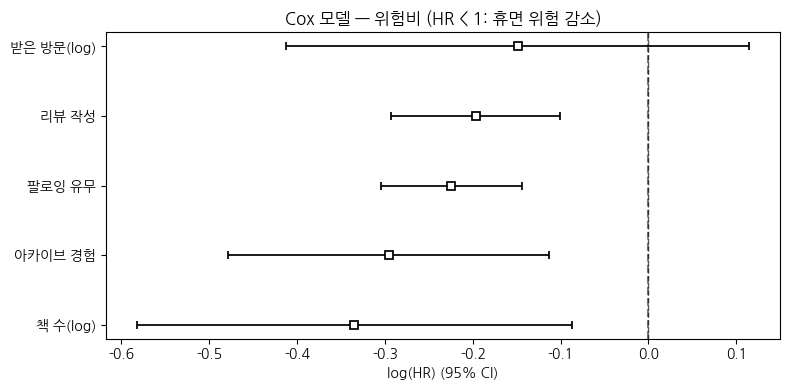

Concordance: 0.665


<lifelines.CoxPHFitter: fitted with 1078 total observations, 87 right-censored observations>
             duration col = 'duration_days'
                event col = 'event_dormant'
      baseline estimation = breslow
   number of observations = 1078
number of events observed = 991
   partial log-likelihood = -6001.408
         time fit was run = 2026-06-15 12:40:46 UTC

---
                 coef exp(coef) exp(coef) lower 95% exp(coef) upper 95%       p
covariate                                                                      
log_books      -0.197     0.821               0.746               0.904 <0.0005
has_unarchived -0.296     0.744               0.620               0.893   0.002
has_follow     -0.149     0.862               0.662               1.122   0.268
has_review     -0.335     0.715               0.558               0.917   0.008
log_visits     -0.225     0.799               0.737               0.866 <0.0005
---
Concordance = 0.665
Partial AIC = 12012.816
log-likelihood ratio test = 180.727 on 5 df
-log2(p) of ll-ratio test = 121.008

In [3]:
# Cox 비례 위험 모델
df['log_books']  = np.log1p(df['total_books'])
df['log_visits'] = np.log1p(df['visits_received_count'])
df['has_follow'] = (df['following_count'] > 0).astype(int)
df['has_review'] = (df['reviews_count'] > 0).astype(int)

COX_COLS = ['duration_days','event_dormant','log_books','has_unarchived',
            'has_follow','has_review','log_visits']
cox_df = df[COX_COLS].dropna()

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='duration_days', event_col='event_dormant')

# 위험비(HR) 시각화
fig, ax = plt.subplots(figsize=(8, 4))
cph.plot(ax=ax)
ax.set_title('Cox 모델 — 위험비 (HR < 1: 휴면 위험 감소)', fontsize=12)
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
labels = ['log_books', 'has_unarchived', 'has_follow', 'has_review', 'log_visits']
ax.set_yticklabels(['책 수(log)', '아카이브 경험', '팔로잉 유무', '리뷰 작성', '받은 방문(log)'])
plt.tight_layout()
plt.savefig('../notebooks/fig_06_cox.png', dpi=150)
plt.show()

print(f"Concordance: {cph.concordance_index_:.3f}")
cph.print_summary(decimals=3, columns=['coef','exp(coef)','p','exp(coef) lower 95%','exp(coef) upper 95%'])


## 인사이트 — Cox 비례 위험 모델

**위험비(HR) 해석 — HR < 1이면 휴면 위험 감소(보호 효과)**

| 변수 | HR | p | 해석 |
|------|-----|---|------|
| has_review | **0.715** | 0.008** | 리뷰 작성자: 휴면 위험 **28.5% 감소** |
| has_unarchived | **0.744** | 0.002** | 아카이브 경험자: 휴면 위험 **25.6% 감소** |
| log_visits | **0.799** | <0.001*** | 받은 방문↑: 휴면 위험 **20.1% 감소** |
| log_books | **0.821** | <0.001*** | 책 수↑: 휴면 위험 **17.9% 감소** |
| has_follow | 0.862 | 0.268 n.s. | **독립 효과 없음** |

**팔로잉의 역설**: Log-rank에서는 p<0.001이었지만 Cox에서 비유의.  
→ 팔로잉 사용자가 오래 머무는 것은 그들이 리뷰·아카이브·방문도 함께 하기 때문.  
팔로잉 자체보다 **리뷰와 아카이브가 진짜 보호 요인**.

**Concordance 0.665**: 예측 정확도 66.5% — 개인별 생존 예측보다 **집단 수준 패턴 파악**에 더 유효.


## 생존 분석 종합 요약

| 가설 | 검정 결과 | 핵심 수치 | 액션 |
|------|----------|----------|------|
| H2: 책 수 → 휴면 低 | **기각** | KM p=0.751 | 책 추가 유도보다 아카이브 유도로 전략 전환 |
| H3: 팔로잉 → 활성 | 지지(KM) / 비독립(Cox) | HR=0.862 n.s. | 팔로잉 강요보다 리뷰+아카이브 먼저 |
| H4: 아카이브 → 활성 | **강력 지지** | HR=0.744 p=0.002** | 온보딩에서 아카이브 최우선 유도 |

**통합 인사이트**: 아카이브와 리뷰 작성이 이 앱에서 가장 강력한 리텐션 행동.  
이 두 행동을 가입 첫 주에 유도하는 것이 모든 단계 분석이 수렴하는 단일 결론.
